# Exercice 3

## Importation de libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.model_selection import train_test_split

## Question 1

Générons 100 points uniformemeant répartis dans le carré $[-1,1]^2$ 

In [3]:
N = 100

In [19]:
X = np.random.uniform(size = (N,2), low=-1, high=1 )
X

array([[ 0.78556154, -0.02321167],
       [ 0.31686508, -0.47800752],
       [ 0.93825888,  0.38139582],
       [ 0.45385879, -0.27391159],
       [ 0.48618545,  0.15760007],
       [-0.61783056, -0.10554595],
       [-0.49728528, -0.10963953],
       [ 0.13430051,  0.07994141],
       [ 0.96933782, -0.82519261],
       [-0.84101738, -0.78411175],
       [-0.13388367,  0.48728368],
       [ 0.08638061,  0.2189913 ],
       [-0.45008737,  0.2332621 ],
       [-0.54341259,  0.43572731],
       [ 0.56985246,  0.28103718],
       [-0.55539228,  0.06653954],
       [-0.94345364, -0.43295561],
       [-0.91079372, -0.56310652],
       [-0.30386843,  0.30819821],
       [-0.14278299, -0.69015244],
       [ 0.43747362,  0.05763147],
       [ 0.59509339, -0.8994145 ],
       [ 0.11688179,  0.43460674],
       [-0.23661243, -0.32710367],
       [ 0.10743573,  0.79652221],
       [ 0.5490077 , -0.80406543],
       [ 0.30804398,  0.16047524],
       [-0.25585699, -0.02921819],
       [ 0.08528391,

In [ ]:
# génération de w sur le cercle unité
theta = np.random.uniform(low=-np.pi, high=np.pi )
w = np.array([np.sin(theta), np.cos(theta)])
w

array([-0.66113581,  0.75026625])

In [20]:
Y= np.sign(np.dot(X,w))
Y

array([-1., -1., -1., -1., -1.,  1.,  1., -1., -1., -1.,  1.,  1.,  1.,
        1., -1.,  1.,  1.,  1.,  1., -1., -1., -1.,  1., -1.,  1., -1.,
       -1.,  1.,  1.,  1., -1.,  1., -1.,  1., -1., -1.,  1., -1.,  1.,
        1.,  1.,  1., -1., -1.,  1., -1., -1.,  1.,  1.,  1., -1.,  1.,
        1.,  1.,  1.,  1., -1., -1.,  1., -1., -1.,  1., -1., -1.,  1.,
        1., -1., -1.,  1., -1., -1., -1.,  1., -1., -1., -1.,  1., -1.,
        1., -1., -1., -1.,  1., -1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,
        1.,  1., -1., -1., -1., -1., -1.,  1.,  1.])

Voici le résultat obtenu

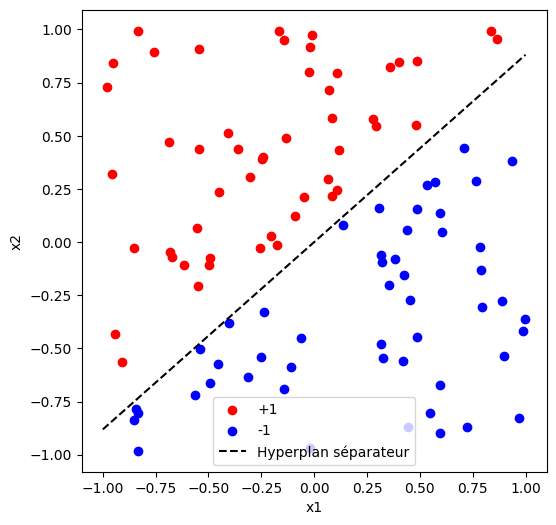

In [28]:
plt.figure(figsize=(6, 6))
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], c='red', label='+1')
plt.scatter(X[Y == -1, 0], X[Y == -1, 1], c='blue', label='-1')
x_w = np.linspace(-1, 1, 100)
y_w = -(w[0] / w[1]) * x_w
plt.plot(x_w, y_w, '--', label='Hyperplan séparateur', color = 'black')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()

    Remarque: ici on considère le cas simple où notre droite(plan séparateur) passe par l'origine. Il est très facile de se ramener à un cas où le plan séparateur ne passe plus par l'origine en ajoutant une colonne égale à 1 à toutes les données. 

# Question 2


On va utiliser la descente en gradient stochastique pour minimiser $L_n(\omega)$. C'est un risque empiriqu equi s'écrit comme une espérance d'une fonction de $\omega$ et de notre échantillon. Cela donne:


1. On se donne $\omega_0$ $\in U_{c}$. Pour nous, il serait légitime de prendre $U_{c}$ = boule unité centrée en 0.

2. On prend la suite $\left( \epsilon_{k}=\frac{1}{k^\alpha} \right)_{k}$ avec $\alpha \in]1/2,1[$, la série associée est bien divergente et la série du carré est bien convergente ce qui nous place dans les hypothèses de convergence. On ne prend pas $\alpha=1$ car en pratique $\alpha \in]1/2,1[$ fonctionne souvent mieux. 

3. Pour un nombre d'itérations fixé on répète:

	4. On tire un échantillon $(x,y)$ au hasard

	5. On calcule le gradient de j en ce point, ici $j(x,y,\omega) =(y-\langle w,x\rangle)^2$ et $\nabla_{\omega} j = -2(y-\langle w,x\rangle)x$

	6. $\omega \leftarrow Proj_{U_{c}}(\omega-\epsilon_{k}\nabla j(x,y,\omega))$

7. On renvoie $\omega$


# Question 3

In [8]:
def grad_j(x,y,w):
    return -2*(y-np.dot(w,x))*x

In [49]:
def grad_desc(X,Y,iter=1000, w0= np.array([1,1]), verbose = False, alpha = 0.8 ):
    w = w0
    for k in range(1,iter+1):
        i = np.random.randint(len(X))
        w = w - ((1/k)**alpha) * grad_j(X[i],Y[i],w)
        w = w /max(1, np.linalg.norm(w)) #projection dans U_c
        if verbose:
            print(w)
    return(w)

In [54]:
estim_w = grad_desc(X,Y)

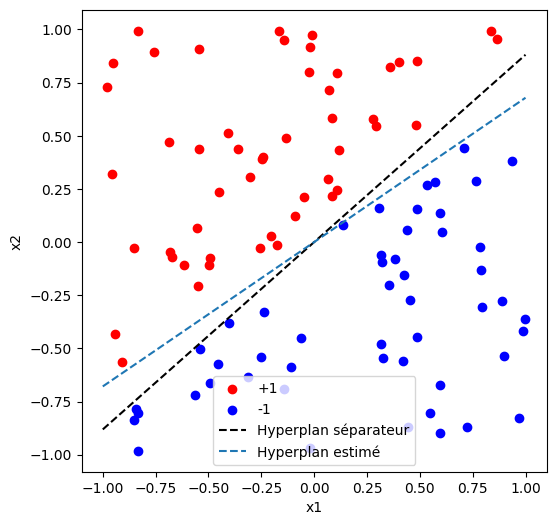

In [55]:
plt.figure(figsize=(6, 6))
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], c='red', label='+1')
plt.scatter(X[Y == -1, 0], X[Y == -1, 1], c='blue', label='-1')
x_w = np.linspace(-1, 1, 100)
y_w = -(w[0] / w[1]) * x_w
y_estim_w = -(estim_w[0] / estim_w[1]) * x_w
plt.plot(x_w, y_w, 'k--', label='Hyperplan séparateur')
plt.plot(x_w, y_estim_w, '--', label='Hyperplan estimé')
plt.legend()
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

# Question 4

In [56]:
# rajoutons un peu de bruit. Var(X1)=Var(X2)=4/12=1/3. Prenons par exemple un quart de cette valeur pour le bruit. 
sigma = 1/12
noisy_X = X + np.random.normal(size = (N,2),loc = 0, scale = sigma)
noisy_X

array([[ 0.70437424, -0.06514604],
       [ 0.41707889, -0.49384701],
       [ 0.9091689 ,  0.50028507],
       [ 0.59994834, -0.27757612],
       [ 0.36275657,  0.11364194],
       [-0.68205778, -0.28058847],
       [-0.39835828, -0.10413538],
       [ 0.34009537,  0.22473038],
       [ 1.12179739, -0.75271624],
       [-0.93211485, -0.76134067],
       [-0.15714326,  0.50606612],
       [ 0.04343784,  0.2258112 ],
       [-0.41777906,  0.43594194],
       [-0.56708196,  0.48264612],
       [ 0.43691135,  0.37841391],
       [-0.60098495,  0.17536329],
       [-0.93430113, -0.37520193],
       [-0.85996866, -0.63379286],
       [-0.30053523,  0.21808823],
       [-0.20103733, -0.55482265],
       [ 0.41951976, -0.06197145],
       [ 0.61650806, -1.06400283],
       [ 0.05160472,  0.48487231],
       [-0.37168743, -0.34788878],
       [ 0.11011781,  0.75146624],
       [ 0.49903201, -0.78051813],
       [ 0.37890922,  0.10508773],
       [-0.2095577 , -0.05454554],
       [ 0.19949116,

In [57]:
estim_noisy_w = grad_desc(noisy_X,Y)

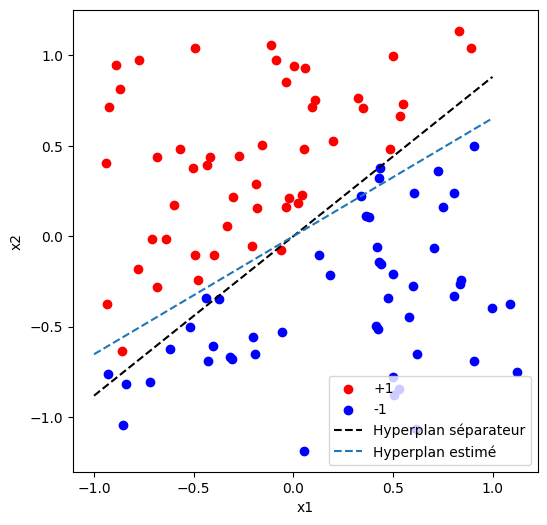

In [58]:
plt.figure(figsize=(6, 6))
plt.scatter(noisy_X[Y == 1, 0], noisy_X[Y == 1, 1], c='red', label='+1')
plt.scatter(noisy_X[Y == -1, 0], noisy_X[Y == -1, 1], c='blue', label='-1')
x_w = np.linspace(-1, 1, 100)
y_w = -(w[0] / w[1]) * x_w
y_estim_w = -(estim_noisy_w[0] / estim_noisy_w[1]) * x_w
plt.plot(x_w, y_w, 'k--', label='Hyperplan séparateur')
plt.plot(x_w, y_estim_w, '--', label='Hyperplan estimé')
plt.legend()
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

    Pour comparer les valeurs, nous utiliserons les matrices de confusion et les métriques classiques (accuracy, f1-score, recall, précision)

In [59]:
Y_pred = np.sign(np.dot(X,estim_w))
Y_pred_noisy = np.sign(np.dot(noisy_X,estim_noisy_w))

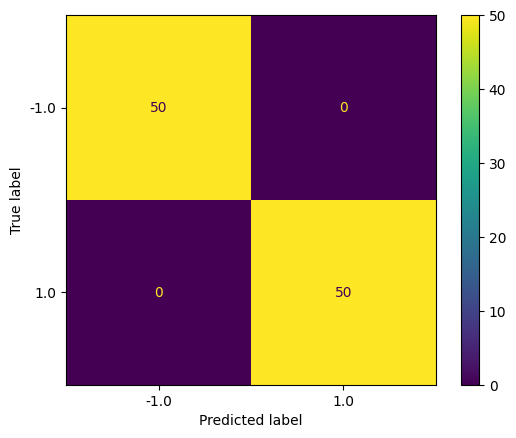

In [60]:
ConfusionMatrixDisplay.from_predictions(Y, Y_pred)

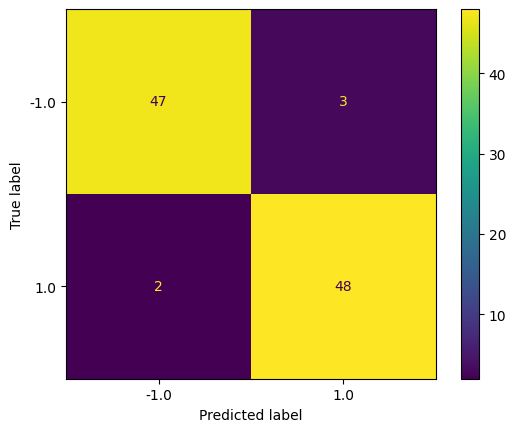

In [61]:
ConfusionMatrixDisplay.from_predictions(Y, Y_pred_noisy)

In [62]:
print(classification_report(Y, Y_pred))

              precision    recall  f1-score   support

        -1.0       1.00      1.00      1.00        50
         1.0       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [63]:
print(classification_report(Y, Y_pred_noisy))

              precision    recall  f1-score   support

        -1.0       0.96      0.94      0.95        50
         1.0       0.94      0.96      0.95        50

    accuracy                           0.95       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100



# Question 5

In [64]:
df_heart= pd.read_csv("heart+disease/processed.cleveland.data" ,index_col=False ,header = None)
df_heart.head(7)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3


In [65]:
df_heart.replace('?', np.nan, inplace=True)

In [66]:
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       303 non-null    float64
 1   1       303 non-null    float64
 2   2       303 non-null    float64
 3   3       303 non-null    float64
 4   4       303 non-null    float64
 5   5       303 non-null    float64
 6   6       303 non-null    float64
 7   7       303 non-null    float64
 8   8       303 non-null    float64
 9   9       303 non-null    float64
 10  10      303 non-null    float64
 11  11      299 non-null    object 
 12  12      301 non-null    object 
 13  13      303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [67]:
# Il n'y a pas beaucoup de valeurs manquantes, on va donc juste supprimer les lignes avec ces valeurs.
df_heart = df_heart.dropna( ignore_index= True)

In [68]:
df_heart.describe()

,0,1,2,3,4,5,6,7,8,9,10,13
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.946128
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,1.234551
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


In [69]:
# notre label est contenu dans la dernière colonne
Y_heart = df_heart[13]
Y_heart

0      0
1      2
2      1
3      0
4      0
      ..
292    1
293    1
294    2
295    3
296    1
Name: 13, Length: 297, dtype: int64

In [70]:
# il faut transformer le vecteur pour mettre les labels à 1 et -1
Y_heart.replace([2,3,4],1, inplace = True)
Y_heart.replace(0,-1, inplace = True)
Y_heart

0     -1
1      1
2      1
3     -1
4     -1
      ..
292    1
293    1
294    1
295    1
296    1
Name: 13, Length: 297, dtype: int64

In [71]:
# on récupère le reste pour faire les prédictions
X_heart= df_heart[[i for i in range(13)]]
X_heart

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,57.0,0.0,4.0,140.0,241.0,0.0,0.0,123.0,1.0,0.2,2.0,0.0,7.0
293,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0
294,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0
295,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0


In [72]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_heart)
X_heart_scaled = pd.DataFrame(X_scaled, columns=X_heart.columns)

In [73]:
# on va ajouter à nos données la colonne  de 1 car on ne sait pas si le plan séparateur passe par l'origine
X_scaled_bar = np.array([np.append(row, 1) for row in X_heart_scaled.values])
X_scaled_bar

array([[ 0.93618065,  0.69109474, -2.24062879, ..., -0.72197605,
         0.65587737,  1.        ],
       [ 1.3789285 ,  0.69109474,  0.87388018, ...,  2.47842525,
        -0.89422007,  1.        ],
       [ 1.3789285 ,  0.69109474,  0.87388018, ...,  1.41162482,
         1.17257652,  1.        ],
       ...,
       [ 1.48961547,  0.69109474,  0.87388018, ...,  1.41162482,
         1.17257652,  1.        ],
       [ 0.27205887,  0.69109474,  0.87388018, ...,  0.34482438,
         1.17257652,  1.        ],
       [ 0.27205887, -1.44697961, -1.20245913, ...,  0.34482438,
        -0.89422007,  1.        ]], shape=(297, 14))

In [79]:
w_heart = grad_desc(X_scaled_bar, Y_heart, w0 = np.ones(14))
w_heart

array([ 0.0625731 ,  0.16218339,  0.27586208,  0.07146929,  0.046835  ,
       -0.05651835,  0.0284439 , -0.14337874,  0.14872901,  0.0371356 ,
        0.11509838,  0.23264473,  0.2758389 , -0.06310528])

In [80]:
Y_pred_heart = np.sign(np.dot(X_scaled_bar, w_heart))
Y_pred_heart

array([-1.,  1.,  1., -1., -1., -1.,  1., -1.,  1.,  1.,  1., -1.,  1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,  1.,  1., -1.,
       -1., -1., -1.,  1., -1.,  1., -1.,  1., -1., -1.,  1.,  1.,  1.,
       -1.,  1., -1., -1., -1., -1.,  1., -1.,  1., -1., -1., -1.,  1.,
       -1., -1.,  1.,  1.,  1., -1.,  1., -1.,  1., -1.,  1., -1.,  1.,
        1., -1., -1.,  1., -1., -1.,  1.,  1.,  1., -1., -1.,  1., -1.,
       -1.,  1.,  1., -1., -1.,  1., -1., -1., -1., -1., -1., -1.,  1.,
        1., -1., -1.,  1.,  1.,  1., -1., -1., -1., -1., -1., -1.,  1.,
       -1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,  1.,  1., -1., -1., -1.,
        1.,  1.,  1.,  1., -1.,  1., -1., -1.,  1.,  1., -1., -1.,  1.,
        1., -1., -1., -1., -1.,  1.,  1.,  1., -1., -1., -1., -1.,  1.,
        1., -1.,  1., -1., -1., -1., -1., -1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1., -1.,  1., -1., -1., -1.,  1., -1.,  1., -1.,  1.,
        1.,  1., -1.,  1.,  1.,  1.,  1., -1., -1.,  1.,  1., -1

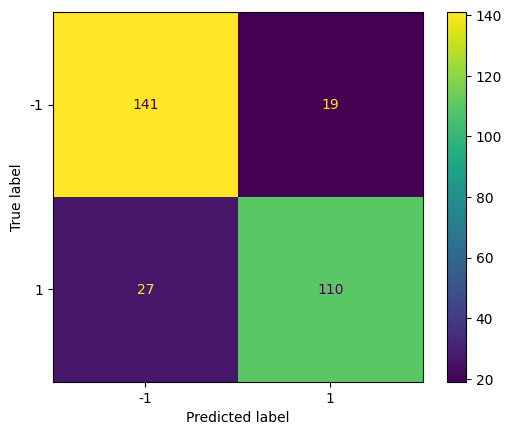

In [81]:
ConfusionMatrixDisplay.from_predictions(Y_heart, Y_pred_heart)

In [82]:
print(classification_report(Y_heart, Y_pred_heart))

              precision    recall  f1-score   support

          -1       0.84      0.88      0.86       160
           1       0.85      0.80      0.83       137

    accuracy                           0.85       297
   macro avg       0.85      0.84      0.84       297
weighted avg       0.85      0.85      0.84       297



    Remarque: pour faire une vraie évaluation, ça serait bien de diviser notre dataset sur le test et le train. Faisons ça rapidement

In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X_heart, Y_heart,          
    test_size=0.2, 
    stratify=Y_heart 
)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Scale using the train
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler  = scaler.transform(X_test)  
X_train_scaled = pd.DataFrame(X_train_scaler , columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaler , columns=X_test.columns)

# Ajout de la colonne de 1
X_train_scaled_bar = np.array([np.append(row, 1) for row in X_train_scaled.values])
X_test_scaled_bar = np.array([np.append(row, 1) for row in X_test_scaled.values])

w_heart = grad_desc(X_train_scaled_bar, y_train, w0 = np.ones(14))
Y_pred_train_heart = np.sign(np.dot(X_train_scaled_bar, w_heart))
Y_pred_test_heart = np.sign(np.dot(X_test_scaled_bar, w_heart))

print('Sur le train:')
print(classification_report(y_train, Y_pred_train_heart))
print('Sur le test:')
print(classification_report(y_test, Y_pred_test_heart))

Sur le train:
              precision    recall  f1-score   support

          -1       0.86      0.88      0.87       128
           1       0.86      0.83      0.84       109

    accuracy                           0.86       237
   macro avg       0.86      0.85      0.86       237
weighted avg       0.86      0.86      0.86       237

Sur le test:
              precision    recall  f1-score   support

          -1       0.79      0.84      0.82        32
           1       0.81      0.75      0.78        28

    accuracy                           0.80        60
   macro avg       0.80      0.80      0.80        60
weighted avg       0.80      0.80      0.80        60



    Nous disposons ici de 13 dimensions pour seulement 237 points dans l’ensemble d’entraînement. Dans un tel cas, il existerait potentiellement de nombreux hyperplans capables de séparer les données si celles-ci étaient linéairement séparables. 
    1. Cependant, les points ne semblent pas se séparer si aisément par un hyperplan unique, ce qui suggère que le dataset n’est probablement pas linéairement séparable.
    2. On devrait peut-etre essayer de réduire les dimensions pour un hyperplan un peu plus stable.
    3. Il serait intéressant d’analyser si les erreurs de classification proviennent principalement des observations issues du label initial particulier. En effet,la classe +1 (valeurs initiales 1,2,3,4) regroupe des observations potentiellement hétérogènes, ce qui peut rendre la séparation linéaire plus difficile.